# Notebook 6: The "Before vs After" Fine-Tuning Comparison
To truly understand the value of our parameter tuning, we must visualize the exact difference between the original "Blind" approach and the "Fine-Tuned" approach side by side.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# The data we collected during our evaluations
blind_censored_count = 33
tuned_censored_count = 7880

historical_max = 4773174.28
blind_prediction = 9641821.53  # Alpha 0.90
tuned_prediction = 8200419.51  # Alpha 0.75


### 1. The Censoring Reality Check (Blind vs Tuned)
A model that only detects 33 capacity limits in half a million transactions is failing to understand supply chain realities. Let's look at the difference our tuning made.


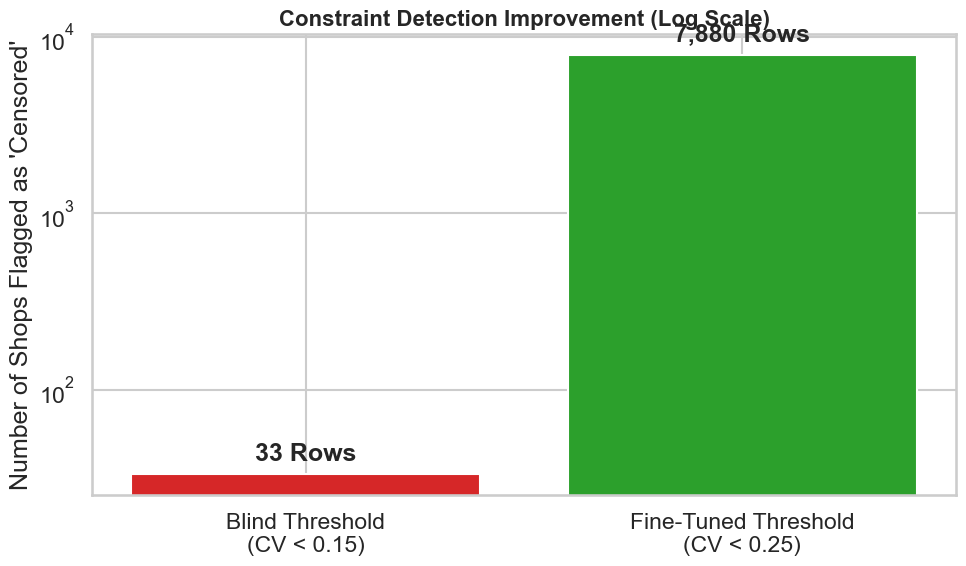

In [2]:
plt.figure(figsize=(10, 6))

bars = plt.bar(['Blind Threshold\n(CV < 0.15)', 'Fine-Tuned Threshold\n(CV < 0.25)'], 
               [blind_censored_count, tuned_censored_count], 
               color=['#d62728', '#2ca02c'])

plt.yscale('log') # Use log scale to show the massive difference clearly

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval * 1.2, f"{yval:,} Rows", ha='center', fontweight='bold')

plt.title("Constraint Detection Improvement (Log Scale)", fontsize=16, fontweight='bold')
plt.ylabel("Number of Shops Flagged as 'Censored'")
plt.tight_layout()
plt.show()


### 2. The Final Growth Target (Blind vs Tuned)
If we tell the boardroom we can double their historical maximum in one month, we lose credibility. Let's visualize how dropping to the Upper Quartile (Alpha=0.75) grounds our prediction in reality.


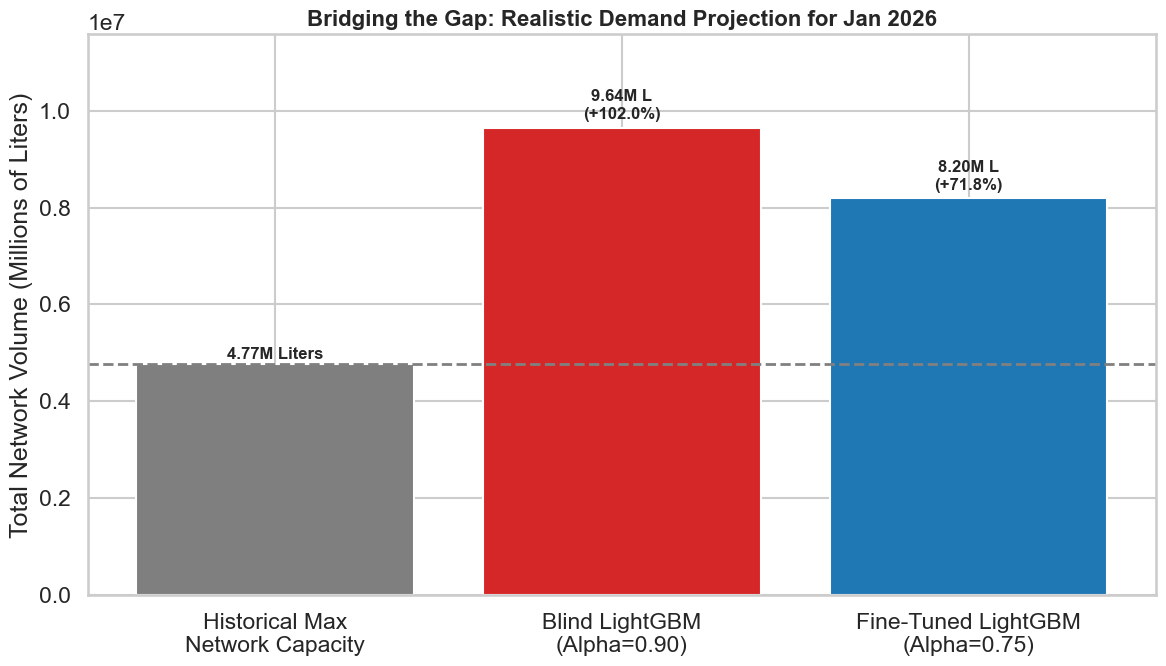

In [3]:
plt.figure(figsize=(12, 7))

x_labels = ['Historical Max\nNetwork Capacity', 'Blind LightGBM\n(Alpha=0.90)', 'Fine-Tuned LightGBM\n(Alpha=0.75)']
values = [historical_max, blind_prediction, tuned_prediction]
colors = ['#7f7f7f', '#d62728', '#1f77b4']

bars = plt.bar(x_labels, values, color=colors)

plt.axhline(historical_max, color='gray', linestyle='--', linewidth=2)

for i, bar in enumerate(bars):
    yval = bar.get_height()
    
    # Calculate percentage growth over historical
    if i == 0:
        label = f"{yval/1e6:.2f}M Liters"
    else:
        pct_growth = ((yval - historical_max) / historical_max) * 100
        label = f"{yval/1e6:.2f}M L\n(+{pct_growth:.1f}%)"
        
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), label, ha='center', fontweight='bold', fontsize=12)

plt.title("Bridging the Gap: Realistic Demand Projection for Jan 2026", fontsize=16, fontweight='bold')
plt.ylabel("Total Network Volume (Millions of Liters)")
plt.ylim(0, blind_prediction * 1.2)
plt.tight_layout()
plt.show()
